In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/20.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/30.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/38.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/42.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/33.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/10.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/35.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/41.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/101.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/37.jpg
/kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india/ITR_Form 16/1.jpg

In [2]:
# ============================================================
# CELLULE 1 — Imports + Constantes
# ============================================================
import os, random, json, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED        = 42
IMG_SIZE    = 224
CONFIDENCE  = 0.90
SAVE_DIR    = '/kaggle/working/checkpoints'
NUM_CLASSES = 5

os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")

✅ Device : cuda


In [4]:
# ============================================================
# CELLULE 2 — Trouver DATA_DIR automatiquement
# ============================================================
print("📁 Contenu /kaggle/input :")
for item in os.listdir('/kaggle/input'):
    path = f'/kaggle/input/{item}'
    print(f"\n  📁 {item}")
    if os.path.isdir(path):
        for sub in os.listdir(path):
            subpath = f'{path}/{sub}'
            if os.path.isdir(subpath):
                n = len(os.listdir(subpath))
                print(f"     📁 {sub}/ ({n} fichiers)")
            else:
                print(f"     📄 {sub}")

# Détection automatique du bon chemin
DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    # On cherche un dossier qui contient les 5 classes
    subdirs = [d for d in dirs if any(
        kw in d.lower() for kw in
        ['bank', 'check', 'itr', 'salary', 'utility']
    )]
    if len(subdirs) >= 3:
        DATA_DIR = root
        break

if DATA_DIR is None:
    # Fallback : prendre le premier dossier avec des sous-dossiers
    for root, dirs, files in os.walk('/kaggle/input'):
        if len(dirs) >= 3:
            DATA_DIR = root
            break

print(f"\n✅ DATA_DIR détecté : {DATA_DIR}")
print(f"   Classes trouvées : {os.listdir(DATA_DIR)}")

📁 Contenu /kaggle/input :

  📁 datasets
     📁 mehaksingal/ (1 fichiers)

✅ DATA_DIR détecté : /kaggle/input/datasets/mehaksingal/personal-financial-dataset-for-india
   Classes trouvées : ['ITR_Form 16', 'Utility', 'Check', 'Bank Statement', 'Salary Slip']


In [5]:
# ============================================================
# CELLULE 3 — Transforms + SafeTransformSubset
# ============================================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, shear=5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class SafeTransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        for attempt in range(len(self.subset)):
            try:
                real_idx = (idx + attempt) % len(self.subset)
                path, label = self.subset.dataset.samples[
                    self.subset.indices[real_idx]]
                img = Image.open(path).convert("RGB")
                return self.transform(img), label
            except: continue
        return torch.zeros(3, IMG_SIZE, IMG_SIZE), 0

print("✅ Transforms + SafeTransformSubset définis")


✅ Transforms + SafeTransformSubset définis


In [9]:
# ============================================================
# CELLULE 4 — Dataset + Distribution + Split + Loaders
# ============================================================
from torchvision import datasets  # ← fix

raw_no_transform = datasets.ImageFolder(root=DATA_DIR, transform=None)
classes          = raw_no_transform.classes
all_targets      = raw_no_transform.targets
all_indices      = list(range(len(raw_no_transform)))
class_counts     = Counter(all_targets)
total            = len(raw_no_transform)
NUM_CLASSES      = len(classes)

# Distribution
print(f"{NUM_CLASSES} classes | {total} images\n")
print(f"{'Classe':<20} {'N':>5}  {'%':>6}")
print("─" * 35)
for i, cls in enumerate(classes):
    n = class_counts[i]
    print(f"{cls:<20} {n:>5}  {n/total*100:>5.1f}%")

# Split stratifié
train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.30, stratify=all_targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=[all_targets[i] for i in temp_idx], random_state=SEED)

train_subset = SafeTransformSubset(Subset(raw_no_transform, train_idx), train_transforms)
val_subset   = SafeTransformSubset(Subset(raw_no_transform, val_idx),   val_transforms)
test_subset  = SafeTransformSubset(Subset(raw_no_transform, test_idx),  val_transforms)

# WeightedRandomSampler
train_targets_list = [all_targets[i] for i in train_idx]
cnt            = Counter(train_targets_list)
sample_weights = [1.0/cnt[t] for t in train_targets_list]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_subset, batch_size=16, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=16, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=16, shuffle=False,    num_workers=2)

# Loss pondérée
counts_all = [class_counts[i] for i in range(NUM_CLASSES)]
w = torch.tensor([1.0/c for c in counts_all], dtype=torch.float).to(DEVICE)
w = w / w.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=w)

print(f"\n✅ Split | Train={len(train_idx)} Val={len(val_idx)} Test={len(test_idx)}")

5 classes | 426 images

Classe                   N       %
───────────────────────────────────
Bank Statement          91   21.4%
Check                  100   23.5%
ITR_Form 16             40    9.4%
Salary Slip             96   22.5%
Utility                 99   23.2%

✅ Split | Train=298 Val=64 Test=64


In [6]:
# ============================================================
# CELLULE 5 — Fonctions train/eval/test + run_training
# ============================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    ls, cor, tot = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        ls  += loss.item() * len(labels)
        cor += (out.argmax(1) == labels).sum().item()
        tot += len(labels)
    return ls/tot, cor/tot

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    ls, cor, tot = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs); loss = criterion(out, labels)
        ls  += loss.item() * len(labels)
        cor += (out.argmax(1) == labels).sum().item()
        tot += len(labels)
    return ls/tot, cor/tot

@torch.no_grad()
def get_test_acc(model, loader):
    model.eval()
    cor, tot, preds_all, labels_all = 0, 0, [], []
    for imgs, labels in loader:
        out = model(imgs.to(DEVICE))
        p   = out.argmax(1).cpu().numpy()
        preds_all.extend(p); labels_all.extend(labels.numpy())
        cor += (out.argmax(1).cpu() == labels).sum().item()
        tot += len(labels)
    return cor/tot, preds_all, labels_all

def build_model(name):
    if name == "resnet18":
        m = models.resnet18(weights=None)
        for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Sequential(nn.Dropout(0.3),
                              nn.Linear(m.fc.in_features, NUM_CLASSES))
    else:
        m = models.efficientnet_b0(weights=None)
        for p in m.parameters(): p.requires_grad = False
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(in_f, 256),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, NUM_CLASSES))
    path = f"{SAVE_DIR}/{name}_final.pth"
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location=DEVICE))
        print(f"✅ Poids chargés depuis {path}")
    return m.to(DEVICE)

def run_training(model, name, train_ldr, epochs_p1=25, epochs_p2=20,
                 lr=3e-4, patience=8):
    # ── Phase 1 : tête seulement ────────────────────────────
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs_p1)

    best_val, patience_c = 0, 0
    print(f"\n🚀 {name} — Phase 1\n")

    for ep in range(1, epochs_p1+1):
        tl, ta = train_epoch(model, train_ldr, optimizer, criterion)
        vl, va = eval_epoch(model, val_loader, criterion)
        scheduler.step()
        flag = ""
        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), f"{SAVE_DIR}/{name}_p1.pth")
            patience_c = 0; flag = " ✅"
        else:
            patience_c += 1
            if patience_c >= patience:
                print(f"⏹ Early stopping ep {ep}"); break
        print(f"Ep {ep:02d} | Train acc={ta:.3f} | Val acc={va:.3f}{flag}")

    print(f"\n✅ Phase 1 — Best val : {best_val:.3f}")

    # ── Phase 2 : backbone dégelé ───────────────────────────
    model.load_state_dict(torch.load(f"{SAVE_DIR}/{name}_p1.pth"))
    for p in model.parameters(): p.requires_grad = True

    if "resnet" in name:
        param_groups = [
            {"params": [p for n,p in model.named_parameters()
                        if "fc" not in n], "lr": 5e-5},
            {"params": model.fc.parameters(), "lr": 1e-4}]
    else:
        param_groups = [
            {"params": model.features.parameters(),   "lr": 5e-5},
            {"params": model.classifier.parameters(), "lr": 1e-4}]

    opt_ft = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    sch_ft = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=epochs_p2)

    best_val_ft, patience_c = best_val, 0
    print(f"\n🚀 {name} — Phase 2\n")

    for ep in range(1, epochs_p2+1):
        tl, ta = train_epoch(model, train_ldr, opt_ft, criterion)
        vl, va = eval_epoch(model, val_loader, criterion)
        sch_ft.step()
        flag = ""
        if va > best_val_ft:
            best_val_ft = va
            torch.save(model.state_dict(), f"{SAVE_DIR}/{name}_final.pth")
            patience_c = 0; flag = " ✅"
        else:
            patience_c += 1
            if patience_c >= patience:
                print(f"⏹ Early stopping ep {ep}"); break
        print(f"Ep {ep:02d} | Train acc={ta:.3f} | Val acc={va:.3f}{flag}")

    print(f"\n✅ {name} terminé — Best val : {best_val_ft:.3f}")
    return model, best_val_ft

print("✅ Toutes les fonctions définies")

✅ Toutes les fonctions définies


In [7]:
# ============================================================
# CELLULE 5b — CNN from scratch (avant ResNet-18)
# ============================================================
import os, json, torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SAVE_DIR    = '/kaggle/working/checkpoints'
DEVICE      = torch.device("cuda" if torch.cuda.is_available()
                             else "cpu")
NUM_CLASSES = 5
classes     = ["Bank Statement", "Check", "ITR_Form 16",
               "Salary Slip", "Utility"]
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Architecture CNN from scratch ────────────────────────────
class FinDocCNN(nn.Module):
    """
    CNN conçu spécifiquement pour les documents financiers.

    Architecture :
    3 blocs Conv → BatchNorm → ReLU → MaxPool → Dropout
    + tête de classification fully connected

    Pourquoi ce design :
    - Les documents financiers ont des features locales
      répétitives (lignes, tableaux, chiffres)
    - Les filtres 3×3 capturent ces patterns fins
    - BatchNorm stabilise l'entraînement sur peu de données
    - Dropout évite l'overfitting (426 images seulement)
    """
    def __init__(self, num_classes=5):
        super().__init__()

        # Bloc 1 — features basse résolution (bords, lignes)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),      # 224 → 112
            nn.Dropout2d(p=0.1)
        )

        # Bloc 2 — features moyennes (tableaux, zones de texte)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),      # 112 → 56
            nn.Dropout2d(p=0.1)
        )

        # Bloc 3 — features hautes (structure globale du doc)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),      # 56 → 28
            nn.Dropout2d(p=0.2)
        )

        # Bloc 4 — abstraction finale
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))  # → 4×4 fixe
        )

        # Tête de classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)


# ── Instancier et vérifier ────────────────────────────────────
cnn_model = FinDocCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in cnn_model.parameters())
trainable_p = sum(p.numel() for p in cnn_model.parameters()
                  if p.requires_grad)

print("✅ CNN from scratch créé")
print(f"   Paramètres totaux      : {total_p:,}")
print(f"   Paramètres entraînables: {trainable_p:,}")
print(f"   (ResNet-18 = 11,181,642 | CNN = {total_p:,})")
print(f"\n   Architecture :")
print(f"   Input   : 3 × 224 × 224")
print(f"   Block1  : Conv(3→32)  → 112×112")
print(f"   Block2  : Conv(32→64) → 56×56")
print(f"   Block3  : Conv(64→128)→ 28×28")
print(f"   Block4  : Conv(128→256)→ 4×4")
print(f"   FC      : 4096 → 512 → 128 → {NUM_CLASSES}")

✅ CNN from scratch créé
   Paramètres totaux      : 2,747,557
   Paramètres entraînables: 2,747,557
   (ResNet-18 = 11,181,642 | CNN = 2,747,557)

   Architecture :
   Input   : 3 × 224 × 224
   Block1  : Conv(3→32)  → 112×112
   Block2  : Conv(32→64) → 56×56
   Block3  : Conv(64→128)→ 28×28
   Block4  : Conv(128→256)→ 4×4
   FC      : 4096 → 512 → 128 → 5


In [10]:
# ── Loss + Optimizer + Scheduler ─────────────────────────────
# Même loss pondérée que ResNet/EfficientNet
counts_all = [class_counts[i] for i in range(NUM_CLASSES)]
w = torch.tensor([1.0/c for c in counts_all],
                  dtype=torch.float).to(DEVICE)
w = w / w.sum() * NUM_CLASSES
criterion_cnn = nn.CrossEntropyLoss(weight=w)

# CNN entraîné de zéro → lr plus élevé que fine-tuning
optimizer_cnn = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn, T_max=40)

print("✅ Loss + Optimizer définis")
print(f"   LR initial : 1e-3 (CNN from scratch)")
print(f"   ResNet LR  : 3e-4 (transfer learning)")
print(f"   Différence : CNN a besoin d'un LR plus élevé")
print(f"                car il part de zéro")

✅ Loss + Optimizer définis
   LR initial : 1e-3 (CNN from scratch)
   ResNet LR  : 3e-4 (transfer learning)
   Différence : CNN a besoin d'un LR plus élevé
                car il part de zéro


In [11]:
# ── Entraînement CNN (40 epochs, plus long que ResNet) ────────
CNN_EPOCHS = 40
best_val   = 0
patience_c = 0
PATIENCE   = 10   # plus patient car entraînement from scratch
history_cnn = {"tl":[], "vl":[], "ta":[], "va":[]}
cnn_path    = f"{SAVE_DIR}/cnn_final.pth"

print("🚀 Entraînement CNN from scratch\n")

for ep in range(1, CNN_EPOCHS + 1):
    tl, ta = train_epoch(cnn_model, train_loader,
                          optimizer_cnn, criterion_cnn)
    vl, va = eval_epoch(cnn_model, val_loader,
                         criterion_cnn)
    scheduler_cnn.step()

    history_cnn["tl"].append(tl)
    history_cnn["vl"].append(vl)
    history_cnn["ta"].append(ta)
    history_cnn["va"].append(va)

    flag = ""
    if va > best_val:
        best_val   = va
        torch.save(cnn_model.state_dict(), cnn_path)
        patience_c = 0
        flag       = " ✅"
    else:
        patience_c += 1
        if patience_c >= PATIENCE:
            print(f"⏹ Early stopping epoch {ep}")
            break

    print(f"Ep {ep:02d}/{CNN_EPOCHS} | "
          f"Train loss={tl:.4f} acc={ta:.3f} | "
          f"Val loss={vl:.4f} acc={va:.3f}{flag}")

print(f"\n✅ CNN entraîné — Best val acc : {best_val:.3f}")

# Sauvegarder metadata
with open(f"{SAVE_DIR}/cnn_meta.json", "w") as f:
    json.dump({"val_acc": best_val,
               "architecture": "CNN_from_scratch",
               "params": total_p}, f)

🚀 Entraînement CNN from scratch



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 01/40 | Train loss=1.6074 acc=0.299 | Val loss=1.6375 acc=0.109 ✅
Ep 02/40 | Train loss=1.4582 acc=0.279 | Val loss=1.6237 acc=0.156 ✅


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 03/40 | Train loss=1.4659 acc=0.319 | Val loss=3.4792 acc=0.094


...

Ep 36/40 | Train loss=0.7772 acc=0.661 | Val loss=0.8955 acc=0.578
Ep 37/40 | Train loss=0.7099 acc=0.698 | Val loss=0.8546 acc=0.609


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 38/40 | Train loss=0.7708 acc=0.658 | Val loss=0.8542 acc=0.594


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


⏹ Early stopping epoch 39

✅ CNN entraîné — Best val acc : 0.672


── Classification Report — CNN from scratch ──

                precision    recall  f1-score   support

Bank Statement       0.85      0.79      0.81        14
         Check       0.94      1.00      0.97        15
   ITR_Form 16       0.25      0.67      0.36         6
   Salary Slip       0.62      0.36      0.45        14
       Utility       0.55      0.40      0.46        15

      accuracy                           0.64        64
     macro avg       0.64      0.64      0.61        64
  weighted avg       0.69      0.64      0.65        64



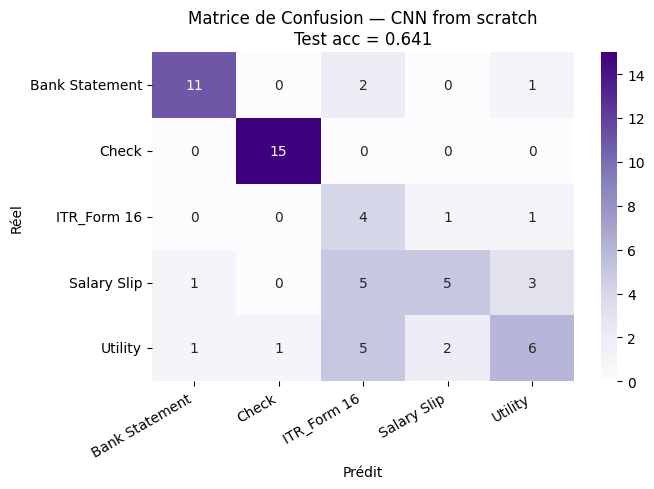

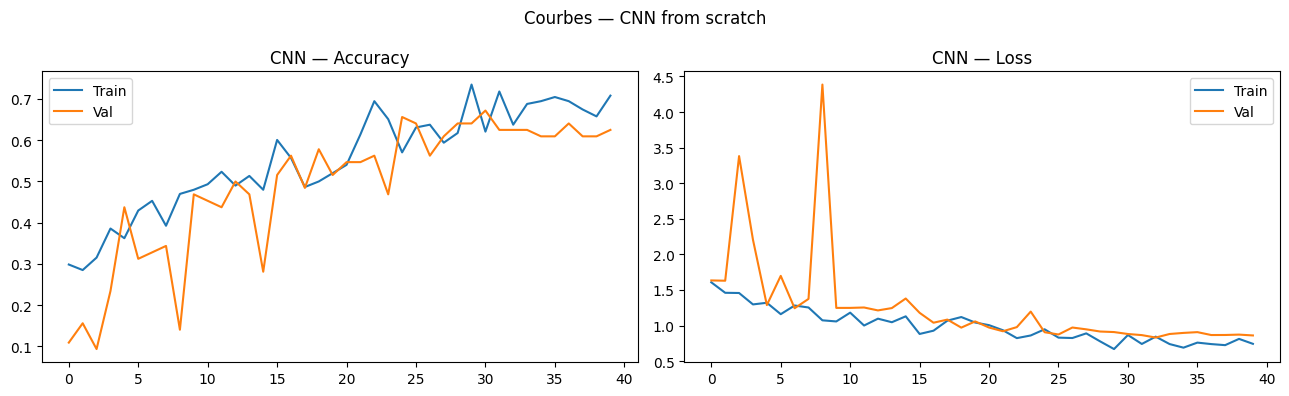


  CNN from scratch test acc : 0.641


In [11]:
# ── Évaluation CNN sur le test set ───────────────────────────
cnn_model.load_state_dict(
    torch.load(cnn_path, map_location=DEVICE))
cnn_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = cnn_model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cnn_test_acc = sum(p==l for p,l in zip(all_preds, all_labels)) \
               / len(all_labels)

print("── Classification Report — CNN from scratch ──\n")
print(classification_report(all_labels, all_preds,
                              target_names=classes))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=classes, yticklabels=classes)
plt.title(f"Matrice de Confusion — CNN from scratch\n"
          f"Test acc = {cnn_test_acc:.3f}")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cm_cnn.png", dpi=150)
plt.show()

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_cnn["ta"], label="Train")
axes[0].plot(history_cnn["va"], label="Val")
axes[0].set_title("CNN — Accuracy"); axes[0].legend()
axes[1].plot(history_cnn["tl"], label="Train")
axes[1].plot(history_cnn["vl"], label="Val")
axes[1].set_title("CNN — Loss"); axes[1].legend()
plt.suptitle("Courbes — CNN from scratch")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/curves_cnn.png", dpi=150)
plt.show()

print(f"\n{'='*50}")
print(f"  CNN from scratch test acc : {cnn_test_acc:.3f}")
print(f"{'='*50}")

with open(f"{SAVE_DIR}/cnn_meta.json", "w") as f:
    json.dump({"val_acc": best_val,
               "test_acc": cnn_test_acc,
               "architecture": "CNN_from_scratch",
               "params": total_p}, f)

✅ Sauvegardé : /kaggle/working/checkpoints/xai_cnn.png


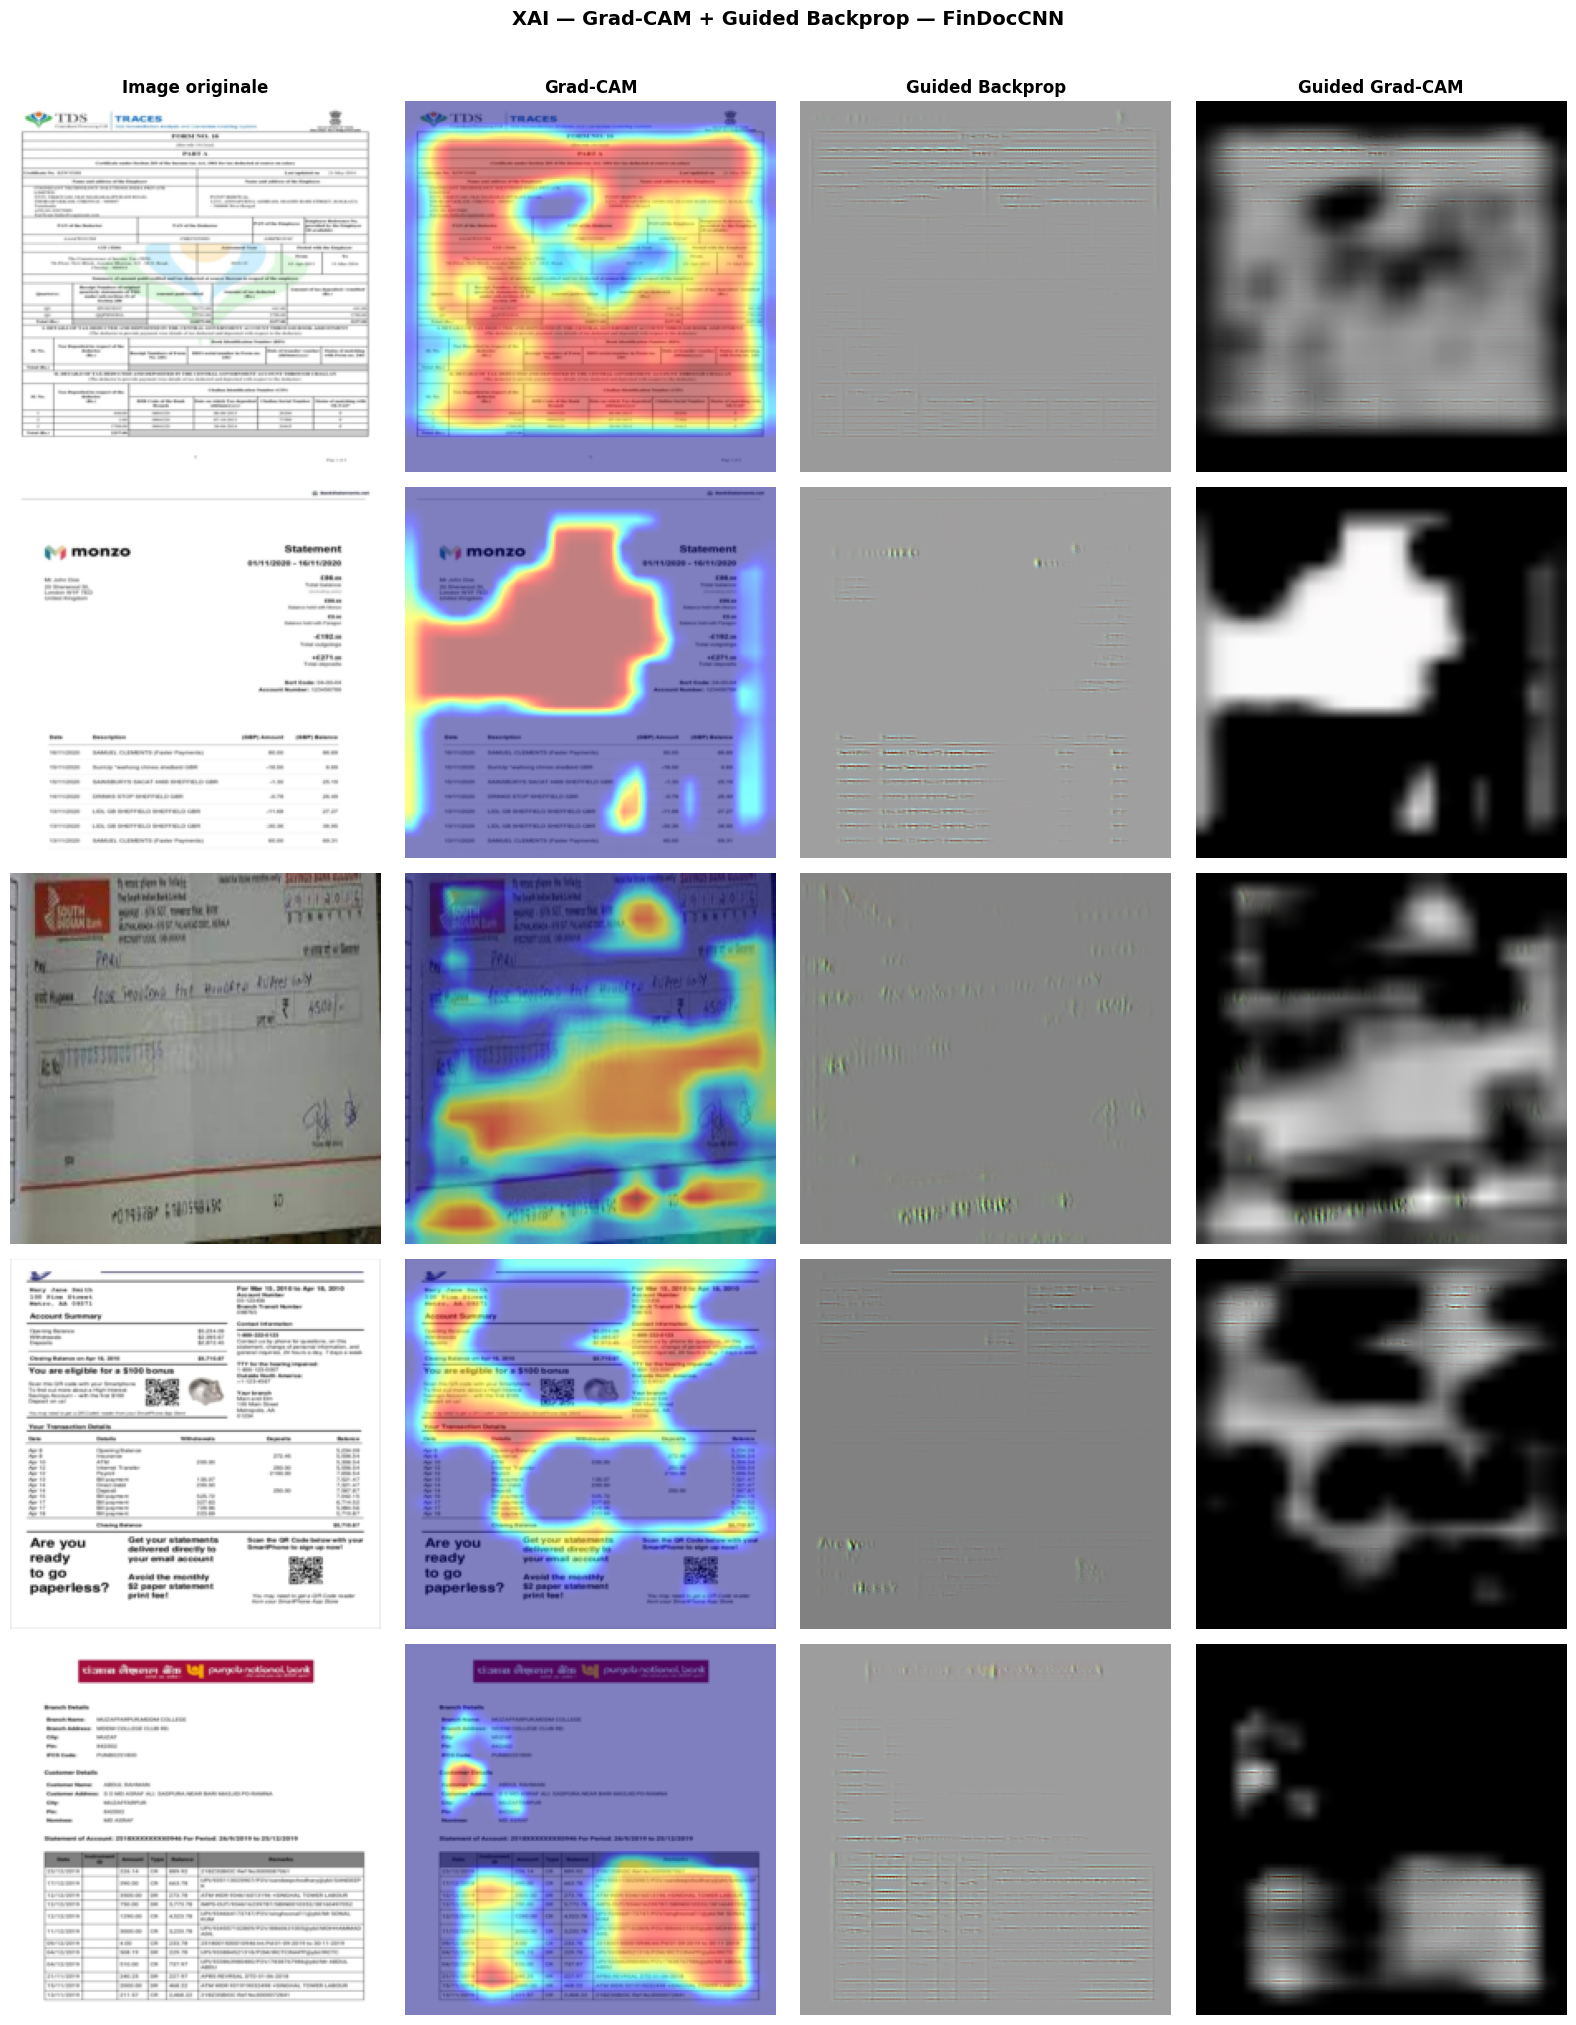

In [13]:
# ============================================================
# XAI — Grad-CAM + Guided Backpropagation — FinDocCNN
# ============================================================
import cv2
from torch.nn import ReLU

# ── 1. Grad-CAM ─────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model      = model
        self.gradients  = None
        self.activations= None
        self.hook_handles = []

        h1 = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        h2 = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))
        self.hook_handles = [h1, h2]

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)                  # forward
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()                   # backward

        # Grad-CAM formula
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # GAP
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)

        # Upsample → taille image
        cam = torch.nn.functional.interpolate(
            cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()


# ── 2. Guided Backpropagation ───────────────────────────────
# ── Fix : désactiver inplace ReLU pour Guided BP ────────────
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, ReLU):
            module.inplace = False

# ── Guided Backpropagation (corrigé) ────────────────────────
class GuidedBackprop:
    def __init__(self, model):
        self.model = model
        self.hooks = []
        disable_inplace_relu(self.model)   # ← FIX ICI
        self._register_hooks()

    def _register_hooks(self):
        def hook_fn(module, grad_in, grad_out):
            return (torch.clamp(grad_in[0], min=0),)

        for module in self.model.modules():
            if isinstance(module, ReLU):
                self.hooks.append(
                    module.register_full_backward_hook(hook_fn))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        inp = input_tensor.clone().requires_grad_(True)
        output = self.model(inp)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        guided = inp.grad.squeeze().cpu().numpy()
        guided = np.transpose(guided, (1, 2, 0))
        guided = (guided - guided.min()) / (guided.max() - guided.min() + 1e-8)
        return guided, class_idx

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        # Restaurer inplace=True après usage
        for module in self.model.modules():
            if isinstance(module, ReLU):
                module.inplace = True
   
 

# ── 3. Guided Grad-CAM (fusion) ─────────────────────────────
def guided_gradcam(guided, cam):
    """Multiplie Guided BP par Grad-CAM upsampled"""
    cam_3ch = np.stack([cam]*3, axis=-1)               # (224,224,3)
    ggc     = guided * cam_3ch
    ggc     = (ggc - ggc.min()) / (ggc.max() - ggc.min() + 1e-8)
    return ggc


# ── 4. Visualisation sur N images du test set ───────────────
def denormalize(tensor, mean=(0.485,0.456,0.406),
                         std =(0.229,0.224,0.225)):
    t = tensor.clone().cpu()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1).permute(1, 2, 0).numpy()


def visualize_xai(model, loader, classes, n_images=5,
                  save_path=None):
    # Initialiser sur block4 (dernière conv)
    target_layer = model.block4[0]   # Conv2d(128→256)
    grad_cam     = GradCAM(model, target_layer)
    guided_bp    = GuidedBackprop(model)

    model.eval()
    images_done = 0
    fig, axes   = plt.subplots(n_images, 4,
                               figsize=(16, 4 * n_images))
    col_titles  = ["Image originale", "Grad-CAM",
                   "Guided Backprop", "Guided Grad-CAM"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for imgs, labels in loader:
        for i in range(imgs.size(0)):
            if images_done >= n_images:
                break

            inp  = imgs[i:i+1].to(DEVICE)
            true = classes[labels[i].item()]

            # Grad-CAM
            cam, pred_idx = grad_cam.generate(inp)
            pred = classes[pred_idx]

            # Guided BP
            guided, _ = guided_bp.generate(inp, pred_idx)

            # Guided Grad-CAM
            ggc = guided_gradcam(guided, cam)

            # Image originale dénormalisée
            orig = denormalize(imgs[i])

            # Heatmap colorée
            heatmap = cv2.applyColorMap(
                (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            overlay = 0.5 * orig + 0.5 * heatmap
            overlay = np.clip(overlay, 0, 1)

            row   = axes[images_done]
            color = "green" if pred == true else "red"

            row[0].imshow(orig)
            row[0].set_ylabel(f"Vrai : {true}\nPrédit : {pred}",
                              color=color, fontsize=9)
            row[1].imshow(overlay)
            row[2].imshow(guided)
            row[3].imshow(ggc)

            for ax in row:
                ax.axis('off')

            images_done += 1
        if images_done >= n_images:
            break

    plt.suptitle("XAI — Grad-CAM + Guided Backprop — FinDocCNN",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Sauvegardé : {save_path}")
    plt.show()

    grad_cam.remove_hooks()
    guided_bp.remove_hooks()


# ── 5. Lancer la visualisation ───────────────────────────────
cnn_model.load_state_dict(
    torch.load(cnn_path, map_location=DEVICE))

visualize_xai(
    model     = cnn_model,
    loader    = test_loader,
    classes   = classes,
    n_images  = 5,
    save_path = f"{SAVE_DIR}/xai_cnn.png"
)

In [14]:
# ============================================================
# CELLULE 6 — ResNet-18
# Si déjà entraîné → saute à cellule 7
# ============================================================
resnet_path = f"{SAVE_DIR}/resnet18_final.pth"

if os.path.exists(resnet_path):
    # ← Déjà entraîné : charge depuis disque
    print("✅ ResNet-18 déjà entraîné — chargement depuis disque")
    resnet = build_model("resnet18").eval()
    with open(f"{SAVE_DIR}/resnet18_meta.json") as f:
        resnet_acc = json.load(f)["test_acc"]
    print(f"   Test acc : {resnet_acc:.3f}")
else:
    # ← Première fois : entraîner
    resnet = models.resnet18(weights="IMAGENET1K_V1")
    for p in resnet.parameters(): p.requires_grad = False
    resnet.fc = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(resnet.fc.in_features, NUM_CLASSES))
    resnet = resnet.to(DEVICE)

    resnet, resnet_val = run_training(resnet, "resnet18", train_loader)
    resnet.load_state_dict(torch.load(f"{SAVE_DIR}/resnet18_final.pth"))
    resnet_acc, resnet_preds, resnet_labels = get_test_acc(resnet, test_loader)

    # Sauvegarde résultats
    with open(f"{SAVE_DIR}/resnet18_meta.json", "w") as f:
        json.dump({"val_acc": resnet_val, "test_acc": resnet_acc}, f)

    print(f"\n{'='*40}")
    print(f"  ResNet-18 test acc : {resnet_acc:.3f}")
    print(f"{'='*40}")
    print(classification_report(resnet_labels, resnet_preds,
                                 target_names=classes))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]



🚀 resnet18 — Phase 1



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 01 | Train acc=0.221 | Val acc=0.141 ✅
Ep 02 | Train acc=0.225 | Val acc=0.094
Ep 03 | Train acc=0.215 | Val acc=0.109


...

Ep 16 | Train acc=0.970 | Val acc=0.922


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 17 | Train acc=0.950 | Val acc=0.953 ✅


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 18 | Train acc=0.980 | Val acc=0.922
Ep 19 | Train acc=0.983 | Val acc=0.906
Ep 20 | Train acc=0.956 | Val acc=0.922

✅ resnet18 terminé — Best val : 0.953

  ResNet-18 test acc : 0.828
                precision    recall  f1-score   support

Bank Statement       1.00      0.93      0.96        14
         Check       1.00      0.87      0.93        15
   ITR_Form 16       0.75      0.50      0.60         6
   Salary Slip       0.76      0.93      0.84        14
       Utility       0.65      0.73      0.69        15

      accuracy                           0.83        64
     macro avg       0.83      0.79      0.80        64
  weighted avg       0.84      0.83      0.83        64



── Classification Report — ResNet-18 Fine-tuned ──

                precision    recall  f1-score   support

Bank Statement       1.00      0.93      0.96        14
         Check       1.00      0.87      0.93        15
   ITR_Form 16       0.75      0.50      0.60         6
   Salary Slip       0.76      0.93      0.84        14
       Utility       0.65      0.73      0.69        15

      accuracy                           0.83        64
     macro avg       0.83      0.79      0.80        64
  weighted avg       0.84      0.83      0.83        64



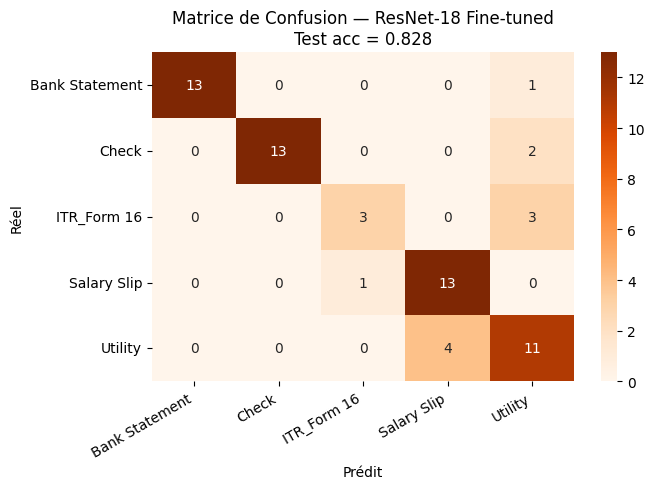


  ResNet-18 test acc : 0.828
  CNN from scratch   : 0.672
  Meilleur modèle    : ResNet-18


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

✅ Sauvegardé : /kaggle/working/checkpoints/xai_lime_resnet18.png


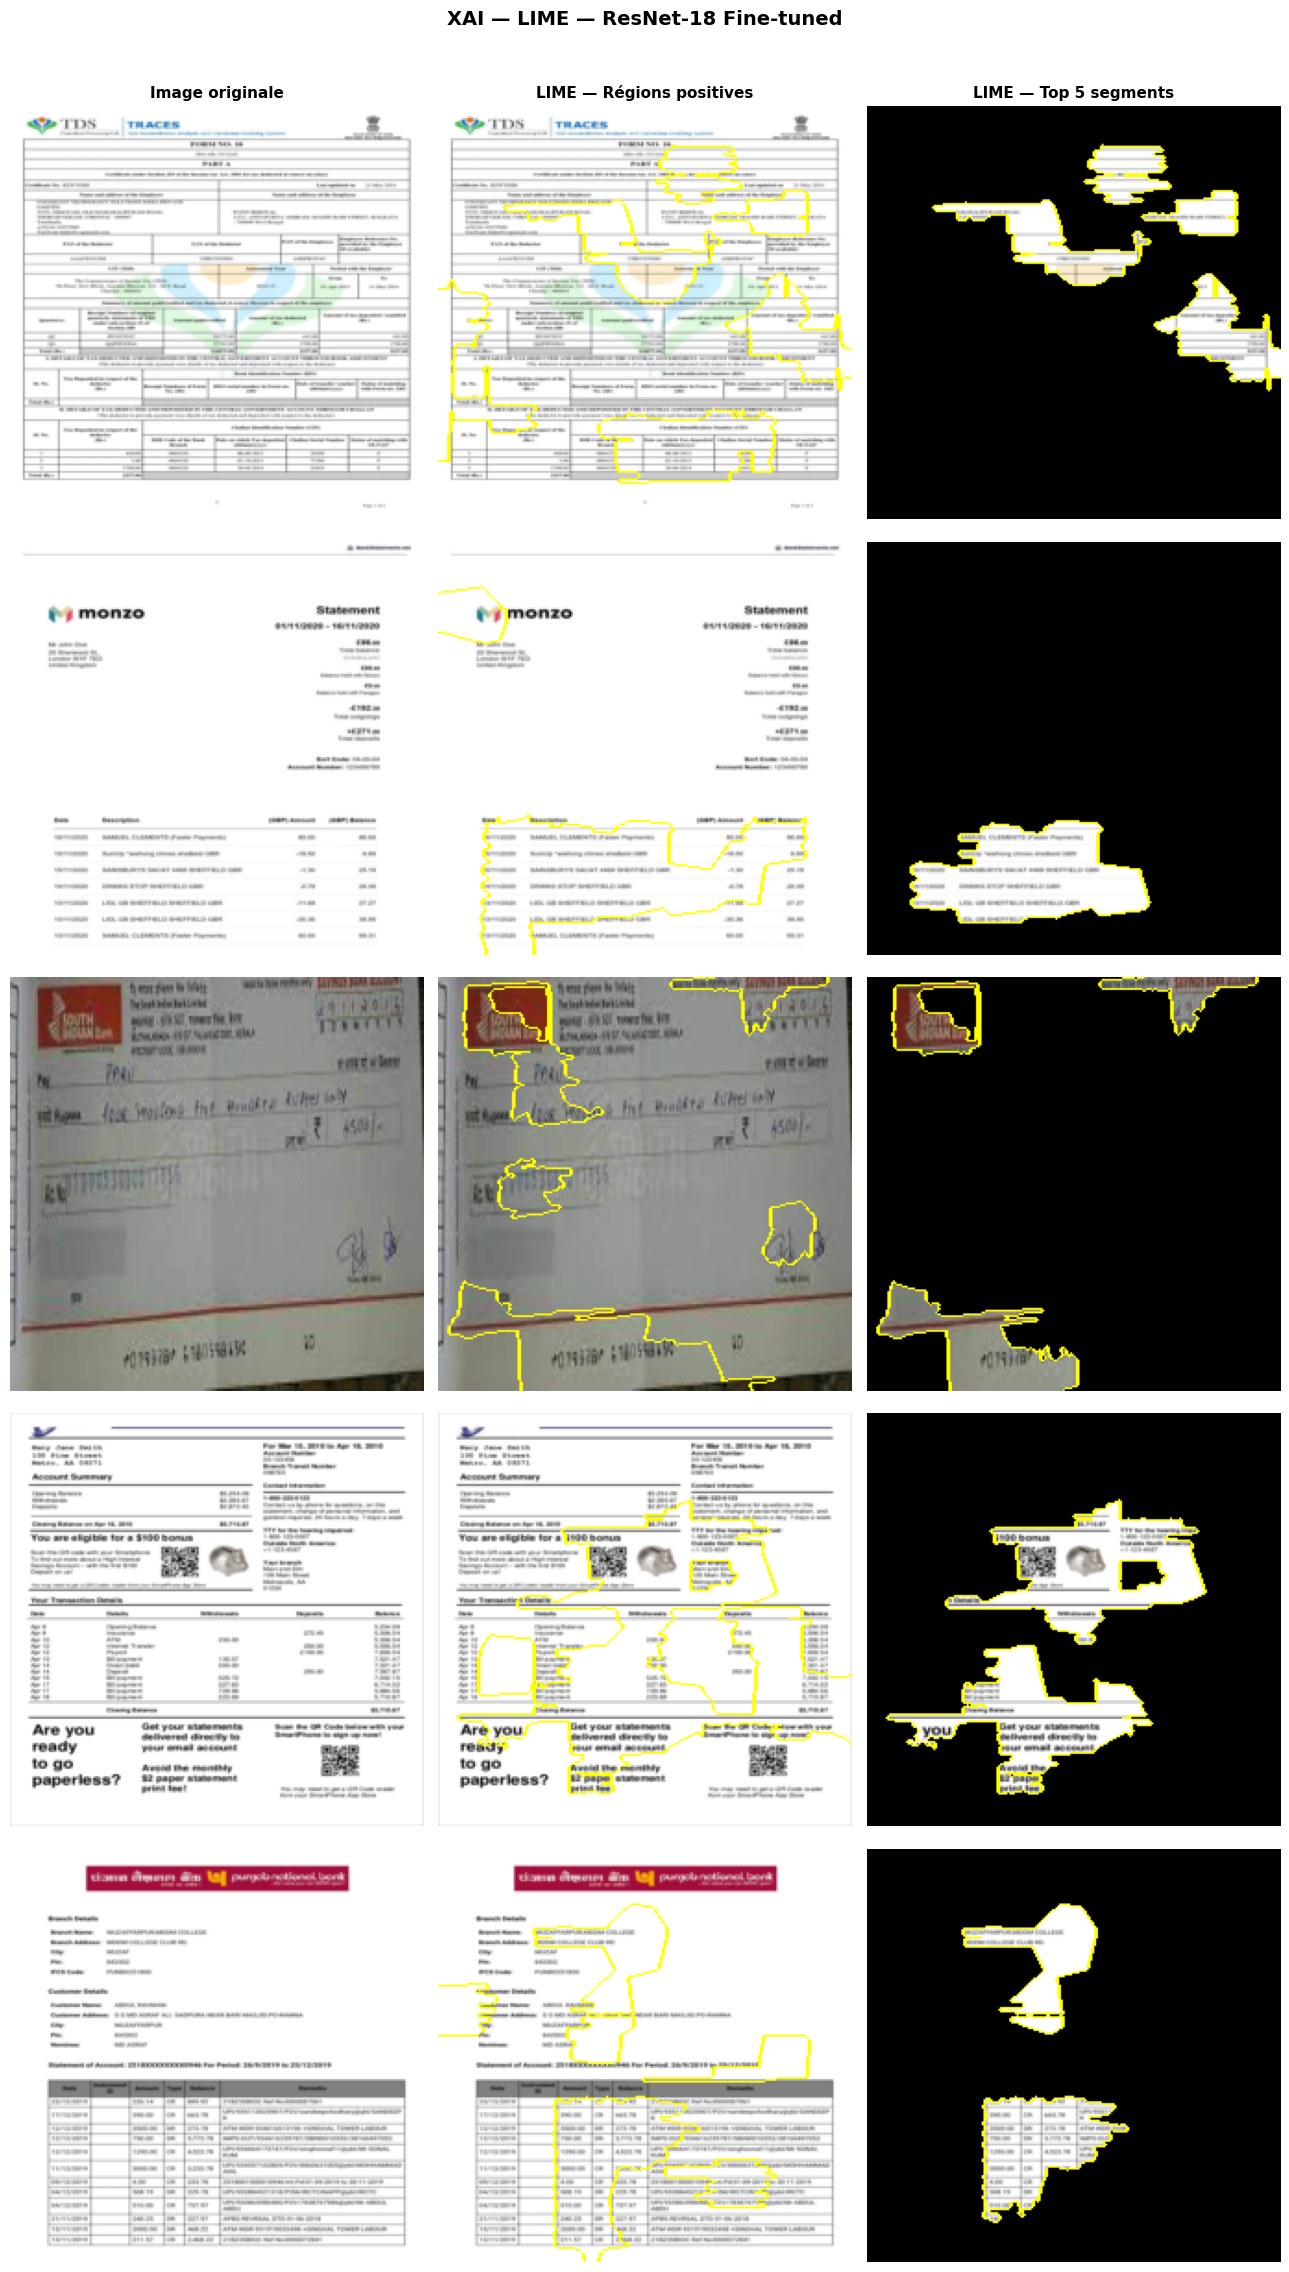

In [20]:
# ============================================================
# CELLULE 7 — Évaluation + XAI LIME — ResNet-18
# ============================================================
!pip install lime -q

from lime import lime_image
from skimage.segmentation import mark_boundaries
import skimage.segmentation as seg
import torch.nn.functional as F

# ── 1. Évaluation ───────────────────────────────────────────
resnet.load_state_dict(torch.load(resnet_path, map_location=DEVICE))
resnet.eval()

all_preds_r, all_labels_r = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = resnet(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds_r.extend(preds)
        all_labels_r.extend(labels.numpy())

resnet_test_acc = sum(p==l for p,l in zip(all_preds_r, all_labels_r)) \
                  / len(all_labels_r)

print("── Classification Report — ResNet-18 Fine-tuned ──\n")
print(classification_report(all_labels_r, all_preds_r,
                              target_names=classes))

# Matrice de confusion
cm_r = confusion_matrix(all_labels_r, all_preds_r)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Oranges",
            xticklabels=classes, yticklabels=classes)
plt.title(f"Matrice de Confusion — ResNet-18 Fine-tuned\n"
          f"Test acc = {resnet_test_acc:.3f}")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cm_resnet18.png", dpi=150)
plt.show()

# ── Fix cnn_test_acc si variable absente ────────────────────
if 'cnn_test_acc' not in dir():
    with open(f"{SAVE_DIR}/cnn_meta.json") as f:
        meta = json.load(f)
        cnn_test_acc = meta.get("test_acc", meta.get("val_acc", 0.0))
    print(f"   (cnn_test_acc chargé : {cnn_test_acc:.3f})")

print(f"\n{'='*50}")
print(f"  ResNet-18 test acc : {resnet_test_acc:.3f}")
print(f"  CNN from scratch   : {cnn_test_acc:.3f}")
winner = "ResNet-18" if resnet_test_acc > cnn_test_acc else "CNN"
print(f"  Meilleur modèle    : {winner}")
print(f"{'='*50}")

with open(f"{SAVE_DIR}/resnet18_meta.json", "w") as f:
    json.dump({"test_acc": resnet_test_acc,
               "architecture": "ResNet18_finetuned"}, f)


# ============================================================
# XAI — LIME — ResNet-18
# ============================================================

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# ── 2. Fonction de prédiction pour LIME ─────────────────────
def predict_fn(images):
    batch = []
    for img in images:
        # ← FIX : float32 au lieu de double
        t = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        t = (t - torch.tensor(mean, dtype=torch.float32).view(3,1,1)) \
          /  torch.tensor(std,  dtype=torch.float32).view(3,1,1)
        batch.append(t)
    batch = torch.stack(batch).to(DEVICE)
    with torch.no_grad():
        logits = resnet(batch)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
    return probs

# ── 3. Dénormalisation ──────────────────────────────────────
def denormalize(tensor):
    t = tensor.clone().cpu()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

# ── 4. Segmentation SLIC ────────────────────────────────────
def slic_segmentation(image, n_segments=80):
    return seg.slic(image, n_segments=n_segments,
                    compactness=10, sigma=1, start_label=0)

# ── 5. Visualisation LIME ───────────────────────────────────
def visualize_lime(model, loader, classes, n_images=5,
                   n_segments=80, n_samples=1000,
                   save_path=None):
    explainer = lime_image.LimeImageExplainer()
    model.eval()

    images_done = 0
    fig, axes  = plt.subplots(n_images, 3,
                               figsize=(13, 4.5 * n_images))
    col_titles = ["Image originale",
                  "LIME — Régions positives",
                  "LIME — Top 5 segments"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight='bold')

    for imgs, labels in loader:
        for i in range(imgs.size(0)):
            if images_done >= n_images:
                break

            orig_np = denormalize(imgs[i])          # (224,224,3) float32
            true    = classes[labels[i].item()]

            with torch.no_grad():
                logits   = model(imgs[i:i+1].to(DEVICE))
                pred_idx = logits.argmax(1).item()
                pred     = classes[pred_idx]
                conf     = F.softmax(logits, dim=1)[0, pred_idx].item()

            # ← FIX : float32 (pas double) pour LIME
            explanation = explainer.explain_instance(
                orig_np.astype(np.float32),
                predict_fn,
                top_labels      = NUM_CLASSES,
                hide_color      = 0,
                num_samples     = n_samples,
                segmentation_fn = lambda x: slic_segmentation(
                                      x, n_segments=n_segments)
            )

            # Régions positives (toutes)
            img_pos, mask_pos = explanation.get_image_and_mask(
                pred_idx,
                positive_only = True,
                num_features  = 10,
                hide_rest     = False
            )
            # Top 5 segments seulement
            img_top, mask_top = explanation.get_image_and_mask(
                pred_idx,
                positive_only = True,
                num_features  = 5,
                hide_rest     = True
            )

            row   = axes[images_done]
            color = "green" if pred == true else "red"

            row[0].imshow(orig_np)
            row[0].set_ylabel(
                f"Vrai  : {true}\nPrédit: {pred} ({conf:.0%})",
                color=color, fontsize=9)
            row[1].imshow(mark_boundaries(img_pos, mask_pos))
            row[2].imshow(mark_boundaries(img_top, mask_top))

            for ax in row:
                ax.axis('off')

            images_done += 1
        if images_done >= n_images:
            break

    plt.suptitle("XAI — LIME — ResNet-18 Fine-tuned",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Sauvegardé : {save_path}")
    plt.show()


# ── 6. Lancer ───────────────────────────────────────────────
visualize_lime(
    model     = resnet,
    loader    = test_loader,
    classes   = classes,
    n_images  = 5,
    n_segments= 80,
    n_samples = 1000,
    save_path = f"{SAVE_DIR}/xai_lime_resnet18.png"
)

In [21]:
# ============================================================
# CELLULE 7 — EfficientNet-B0
# Si déjà entraîné → saute à cellule 8
# ============================================================
effnet_path = f"{SAVE_DIR}/efficientnet_final.pth"

if os.path.exists(effnet_path):
    print("✅ EfficientNet déjà entraîné — chargement depuis disque")
    effnet = build_model("efficientnet").eval()
    with open(f"{SAVE_DIR}/efficientnet_meta.json") as f:
        effnet_acc = json.load(f)["test_acc"]
    print(f"   Test acc : {effnet_acc:.3f}")
else:
    effnet = models.efficientnet_b0(weights="IMAGENET1K_V1")
    for p in effnet.parameters(): p.requires_grad = False
    in_f = effnet.classifier[1].in_features
    effnet.classifier = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, NUM_CLASSES))
    effnet = effnet.to(DEVICE)

    effnet, effnet_val = run_training(effnet, "efficientnet", train_loader)
    effnet.load_state_dict(torch.load(f"{SAVE_DIR}/efficientnet_final.pth"))
    effnet_acc, effnet_preds, effnet_labels = get_test_acc(effnet, test_loader)

    with open(f"{SAVE_DIR}/efficientnet_meta.json", "w") as f:
        json.dump({"val_acc": effnet_val, "test_acc": effnet_acc}, f)

    print(f"\n{'='*40}")
    print(f"  EfficientNet test acc : {effnet_acc:.3f}")
    print(f"{'='*40}")
    print(classification_report(effnet_labels, effnet_preds,
                                 target_names=classes))

# Comparaison baseline
print(f"\n  ResNet-18    : {resnet_acc:.3f}")
print(f"  EfficientNet : {effnet_acc:.3f}")
baseline_winner = "resnet18" if resnet_acc >= effnet_acc else "efficientnet"
baseline_score  = max(resnet_acc, effnet_acc)
print(f"  Gagnant      : {baseline_winner} ({baseline_score:.3f})")

with open(f"{SAVE_DIR}/baseline_winner.json", "w") as f:
    json.dump({"winner": baseline_winner, "score": baseline_score,
               "resnet_acc": resnet_acc, "effnet_acc": effnet_acc}, f)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 



🚀 efficientnet — Phase 1



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 01 | Train acc=0.272 | Val acc=0.297 ✅


...

Ep 07 | Train acc=0.826 | Val acc=0.828
Ep 08 | Train acc=0.859 | Val acc=0.812


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 09 | Train acc=0.859 | Val acc=0.812
Ep 10 | Train acc=0.862 | Val acc=0.859 ✅
Ep 11 | Train acc=0.859 | Val acc=0.844
Ep 12 | Train acc=0.930 | Val acc=0.859
Ep 13 | Train acc=0.899 | Val acc=0.859


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Ep 14 | Train acc=0.886 | Val acc=0.859
Ep 15 | Train acc=0.883 | Val acc=0.859
Ep 16 | Train acc=0.876 | Val acc=0.859
Ep 17 | Train acc=0.896 | Val acc=0.859
Ep 18 | Train acc=0.903 | Val acc=0.875 ✅
Ep 19 | Train acc=0.943 | Val acc=0.875
Ep 20 | Train acc=0.866 | Val acc=0.859

✅ efficientnet terminé — Best val : 0.875

  EfficientNet test acc : 0.844
                precision    recall  f1-score   support

Bank Statement       1.00      0.79      0.88        14
         Check       0.88      1.00      0.94        15
   ITR_Form 16       0.57      0.67      0.62         6
   Salary Slip       0.92      0.79      0.85        14
       Utility       0.76      0.87      0.81        15

      accuracy                           0.84        64
     macro avg       0.83      0.82      0.82        64
  weighted avg       0.86      0.84      0.85        64


  ResNet-18    : 0.828
  EfficientNet : 0.844
  Gagnant      : efficientnet (0.844)


── Classification Report — EfficientNet-B0 ──

                precision    recall  f1-score   support

Bank Statement       1.00      0.79      0.88        14
         Check       0.88      1.00      0.94        15
   ITR_Form 16       0.57      0.67      0.62         6
   Salary Slip       0.92      0.79      0.85        14
       Utility       0.76      0.87      0.81        15

      accuracy                           0.84        64
     macro avg       0.83      0.82      0.82        64
  weighted avg       0.86      0.84      0.85        64



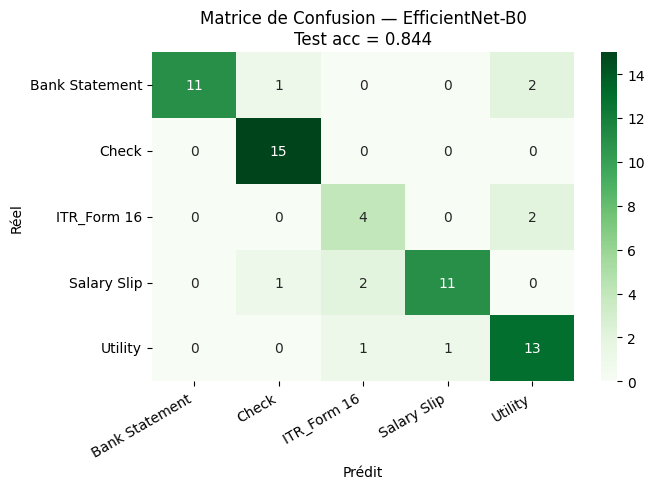


  EfficientNet-B0  : 0.844
  ResNet-18        : 0.828
  CNN from scratch : 0.672
  Meilleur modèle  : EfficientNet (0.844)
                                                                      cclusion...
✅ Sauvegardé : /kaggle/working/checkpoints/xai_occlusion_effnet.png


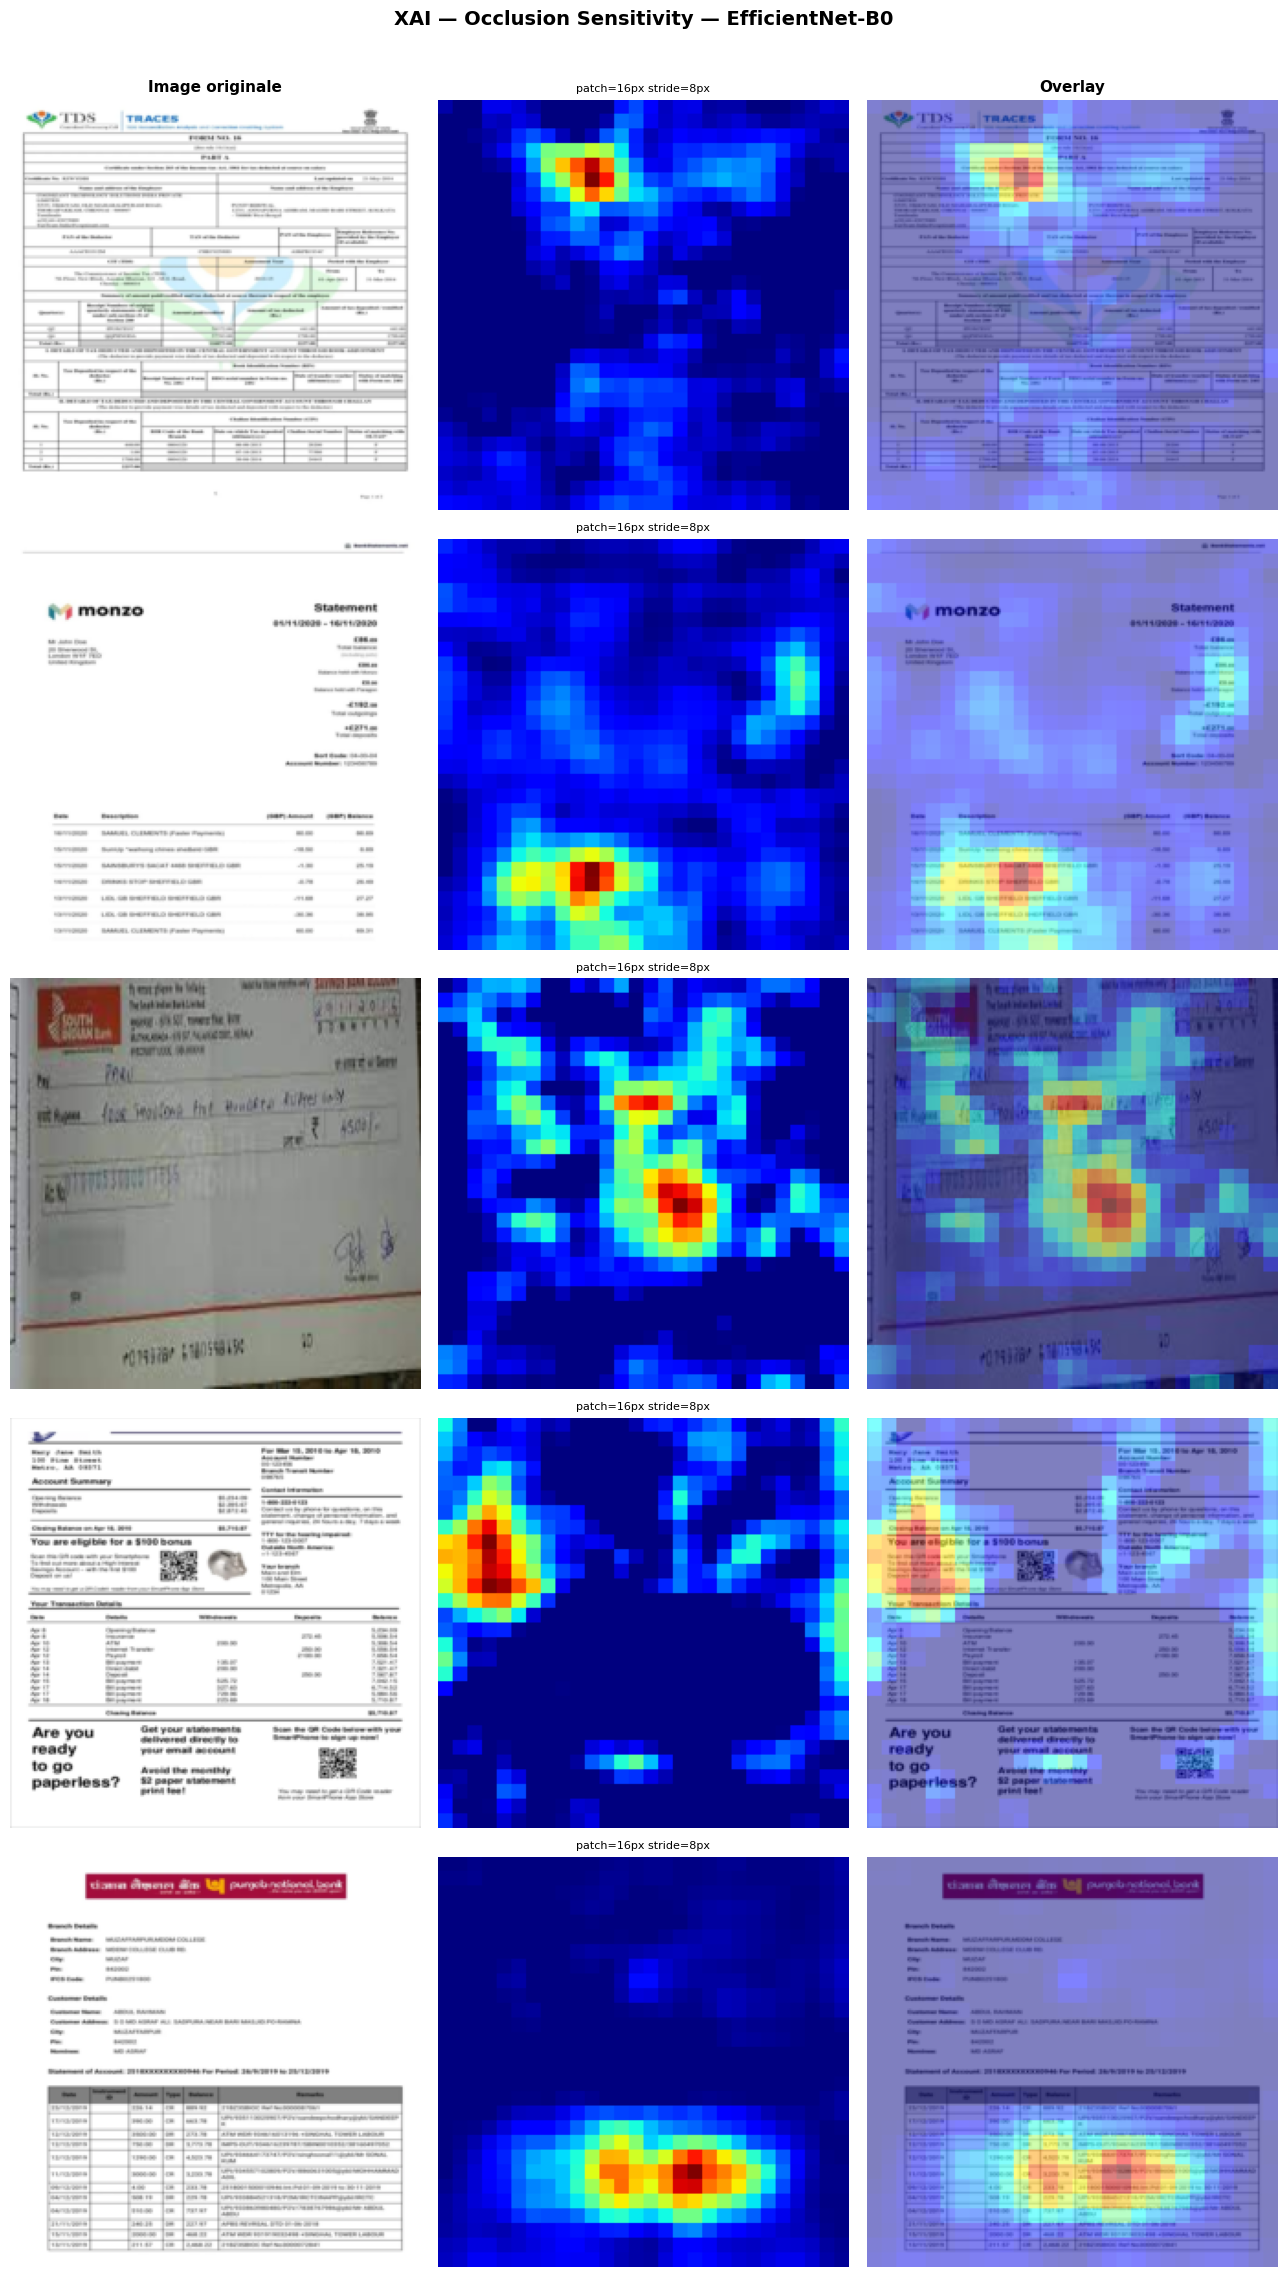

In [22]:
# ============================================================
# CELLULE 8 — Évaluation + XAI Occlusion Sensitivity — EfficientNet-B0
# ============================================================
import torch.nn.functional as F

# ── 1. Évaluation ───────────────────────────────────────────
effnet.load_state_dict(torch.load(effnet_path, map_location=DEVICE))
effnet.eval()

all_preds_e, all_labels_e = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = effnet(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds_e.extend(preds)
        all_labels_e.extend(labels.numpy())

effnet_test_acc = sum(p==l for p,l in zip(all_preds_e, all_labels_e)) \
                  / len(all_labels_e)

print("── Classification Report — EfficientNet-B0 ──\n")
print(classification_report(all_labels_e, all_preds_e,
                              target_names=classes))

# Matrice de confusion
cm_e = confusion_matrix(all_labels_e, all_preds_e)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_e, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes)
plt.title(f"Matrice de Confusion — EfficientNet-B0\n"
          f"Test acc = {effnet_test_acc:.3f}")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cm_effnet.png", dpi=150)
plt.show()

# ── Fix variables absentes ───────────────────────────────────
if 'cnn_test_acc' not in dir():
    with open(f"{SAVE_DIR}/cnn_meta.json") as f:
        meta = json.load(f)
        cnn_test_acc = meta.get("test_acc", meta.get("val_acc", 0.0))

if 'resnet_test_acc' not in dir():
    with open(f"{SAVE_DIR}/resnet18_meta.json") as f:
        resnet_test_acc = json.load(f).get("test_acc", 0.0)

print(f"\n{'='*50}")
print(f"  EfficientNet-B0  : {effnet_test_acc:.3f}")
print(f"  ResNet-18        : {resnet_test_acc:.3f}")
print(f"  CNN from scratch : {cnn_test_acc:.3f}")
scores = {"EfficientNet": effnet_test_acc,
          "ResNet-18":    resnet_test_acc,
          "CNN":          cnn_test_acc}
winner = max(scores, key=scores.get)
print(f"  Meilleur modèle  : {winner} ({scores[winner]:.3f})")
print(f"{'='*50}")

with open(f"{SAVE_DIR}/efficientnet_meta.json", "w") as f:
    json.dump({"test_acc": effnet_test_acc,
               "architecture": "EfficientNet_B0_finetuned"}, f)


# ============================================================
# XAI — Occlusion Sensitivity — EfficientNet-B0
# ============================================================

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# ── 2. Dénormalisation ──────────────────────────────────────
def denormalize(tensor):
    t = tensor.clone().cpu()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

# ── 3. Occlusion Sensitivity ────────────────────────────────
def occlusion_sensitivity(model, input_tensor, class_idx,
                           patch_size=16, stride=8):
    """
    Fait glisser un patch gris sur l'image,
    mesure la chute de confiance à chaque position.
    Plus la chute est grande → plus la zone est importante.
    """
    model.eval()
    C, H, W = input_tensor.shape[1], input_tensor.shape[2], \
               input_tensor.shape[3]

    # Score de référence (sans occlusion)
    with torch.no_grad():
        base_score = F.softmax(model(input_tensor), dim=1) \
                      [0, class_idx].item()

    # Carte de sensibilité
    sens_map = np.zeros((H, W), dtype=np.float32)
    count_map= np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = input_tensor.clone()
            # Patch gris (valeur 0 après normalisation ≈ gris moyen)
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0.0

            with torch.no_grad():
                score = F.softmax(model(occluded), dim=1) \
                         [0, class_idx].item()

            drop = base_score - score          # chute = importance
            sens_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size] += 1

    count_map = np.maximum(count_map, 1)
    sens_map  = sens_map / count_map

    # Normaliser [0, 1]
    sens_map = np.maximum(sens_map, 0)
    s_min, s_max = sens_map.min(), sens_map.max()
    if s_max > s_min:
        sens_map = (sens_map - s_min) / (s_max - s_min)
    return sens_map


# ── 4. Visualisation ────────────────────────────────────────
def visualize_occlusion(model, loader, classes, n_images=5,
                         patch_size=16, stride=8,
                         save_path=None):
    model.eval()

    images_done = 0
    fig, axes  = plt.subplots(n_images, 3,
                               figsize=(13, 4.5 * n_images))
    col_titles = ["Image originale",
                  "Occlusion Sensitivity (heatmap)",
                  "Overlay"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight='bold')

    for imgs, labels in loader:
        for i in range(imgs.size(0)):
            if images_done >= n_images:
                break

            inp      = imgs[i:i+1].to(DEVICE)
            orig_np  = denormalize(imgs[i])
            true     = classes[labels[i].item()]

            with torch.no_grad():
                logits   = model(inp)
                pred_idx = logits.argmax(1).item()
                pred     = classes[pred_idx]
                conf     = F.softmax(logits, dim=1)[0, pred_idx].item()

            print(f"  [{images_done+1}/{n_images}] "
                  f"Vrai: {true} | Prédit: {pred} "
                  f"({conf:.0%}) — calcul occlusion...", end="\r")

            # Carte d'occlusion
            sens_map = occlusion_sensitivity(
                model, inp, pred_idx,
                patch_size=patch_size, stride=stride)

            # Heatmap colorée
            import cv2
            heatmap = cv2.applyColorMap(
                (sens_map * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

            # Overlay
            overlay = 0.5 * orig_np + 0.5 * heatmap
            overlay = np.clip(overlay, 0, 1)

            row   = axes[images_done]
            color = "green" if pred == true else "red"

            row[0].imshow(orig_np)
            row[0].set_ylabel(
                f"Vrai  : {true}\nPrédit: {pred} ({conf:.0%})",
                color=color, fontsize=9)
            row[1].imshow(sens_map, cmap="jet")
            row[1].set_title(f"patch={patch_size}px stride={stride}px",
                             fontsize=8)
            row[2].imshow(overlay)

            for ax in row:
                ax.axis('off')

            images_done += 1
        if images_done >= n_images:
            break

    print(" " * 70)   # effacer la ligne de progression
    plt.suptitle("XAI — Occlusion Sensitivity — EfficientNet-B0",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Sauvegardé : {save_path}")
    plt.show()


# ── 5. Lancer ───────────────────────────────────────────────
# patch_size=16, stride=8 → bon compromis précision/vitesse
# Pour plus de précision  → patch_size=8,  stride=4  (plus lent)
# Pour plus de vitesse    → patch_size=32, stride=16 (moins précis)
visualize_occlusion(
    model      = effnet,
    loader     = test_loader,
    classes    = classes,
    n_images   = 5,
    patch_size = 16,
    stride     = 8,
    save_path  = f"{SAVE_DIR}/xai_occlusion_effnet.png"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.1 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Modèle : resnet18
✅ GradCAM initialisé


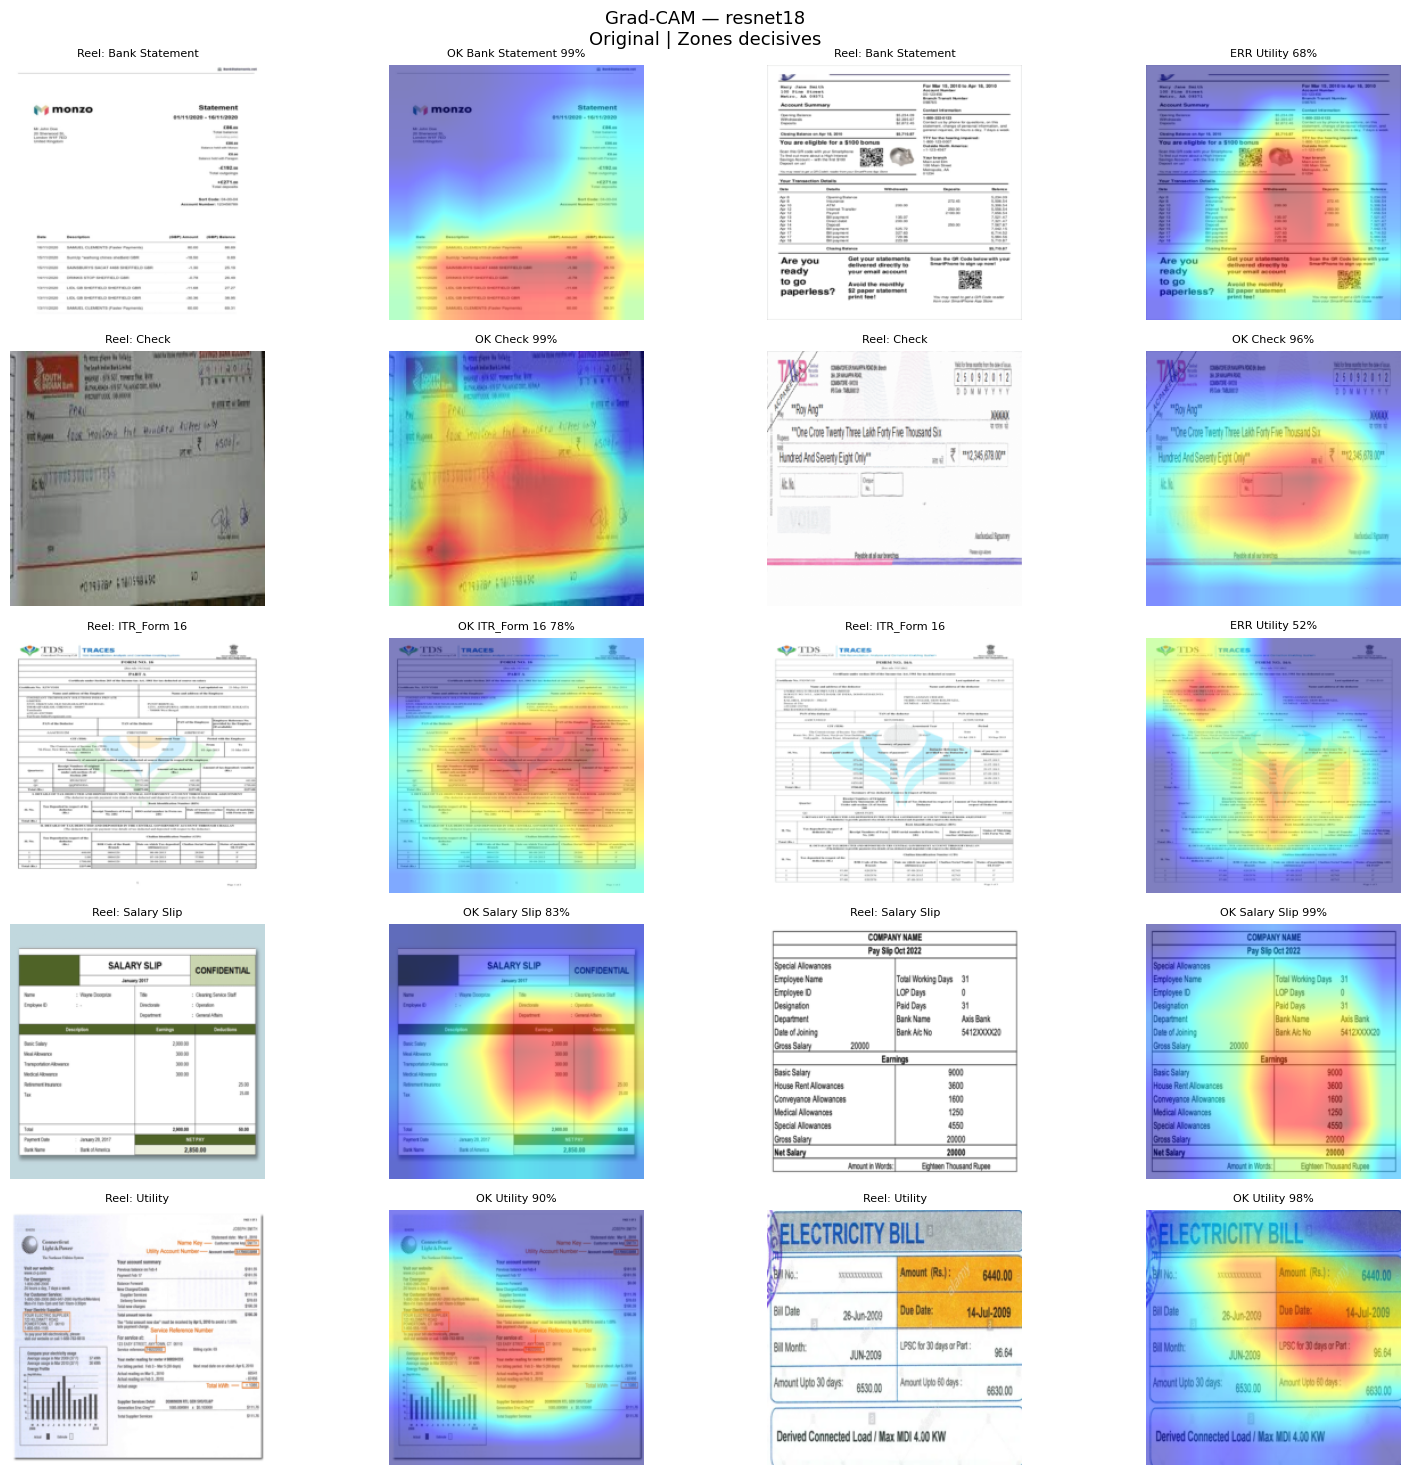

✅ Grad-CAM sauvegarde


In [9]:
# ============================================================
# CELLULE 8 — Grad-CAM (fix complet)
# ============================================================
import os, json, torch, numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
from PIL import Image

SAVE_DIR    = '/kaggle/working/checkpoints'
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5
IMG_SIZE    = 224
classes     = ["Bank Statement", "Check", "ITR_Form 16", "Salary Slip", "Utility"]

!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Charger le gagnant
with open(f"{SAVE_DIR}/baseline_winner.json") as f:
    meta = json.load(f)
baseline_winner = meta["winner"]
print(f"✅ Modèle : {baseline_winner}")

# ── Reconstruire avec requires_grad=True partout ─────────────
import torch.nn as nn
if baseline_winner == "resnet18":
    best_model = models.resnet18(weights=None)
    best_model.fc = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(best_model.fc.in_features, NUM_CLASSES))
    target_layers = [best_model.layer4[-1]]
else:
    best_model = models.efficientnet_b0(weights=None)
    in_f = best_model.classifier[1].in_features
    best_model.classifier = nn.Sequential(
        nn.Dropout(0.4), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, NUM_CLASSES))
    target_layers = [best_model.features[-1]]

# Charger les poids
best_model.load_state_dict(
    torch.load(f"{SAVE_DIR}/{baseline_winner}_final.pth", map_location=DEVICE))

# ← CRITIQUE : activer les gradients sur TOUS les paramètres
for param in best_model.parameters():
    param.requires_grad = True

best_model = best_model.to(DEVICE)
best_model.eval()

# Créer le GradCAM
cam = GradCAM(model=best_model, target_layers=target_layers)
print("✅ GradCAM initialisé")

# ── Transforms inverse pour visualisation ───────────────────
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Collecter 2 images par classe depuis test_subset ─────────
samples = {i: [] for i in range(NUM_CLASSES)}
for idx in range(len(test_subset)):
    img_t, lbl = test_subset[idx]
    if len(samples[lbl]) < 2:
        samples[lbl].append((img_t, lbl))
    if all(len(v) >= 2 for v in samples.values()):
        break

# ── Grille Grad-CAM ──────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(16, NUM_CLASSES * 3))
fig.suptitle(f"Grad-CAM — {baseline_winner}\nOriginal | Zones decisives",
             fontsize=13)

for row, (cls_idx, smpls) in enumerate(samples.items()):
    for col, (img_t, lbl) in enumerate(smpls):
        orig = np.clip(inv_norm(img_t).permute(1, 2, 0).numpy(), 0, 1)
        inp  = img_t.unsqueeze(0).to(DEVICE)
        inp.requires_grad_(True)   # ← forcer gradient sur l'input

        # Prédiction
        logits = best_model(inp)
        pred   = logits.argmax(1).item()
        conf   = torch.softmax(logits, dim=1)[0, pred].item()

        # Grad-CAM sans no_grad
        grayscale = cam(
            input_tensor=inp,
            targets=[ClassifierOutputTarget(pred)]
        )[0]
        cam_img = show_cam_on_image(orig.astype(np.float32),
                                    grayscale, use_rgb=True)

        mark = "OK" if pred == lbl else "ERR"

        axes[row][col*2].imshow(orig)
        axes[row][col*2].set_title(f"Reel: {classes[lbl]}", fontsize=8)
        axes[row][col*2].axis("off")

        axes[row][col*2+1].imshow(cam_img)
        axes[row][col*2+1].set_title(
            f"{mark} {classes[pred]} {conf:.0%}", fontsize=8)
        axes[row][col*2+1].axis("off")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/gradcam_{baseline_winner}.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Grad-CAM sauvegarde")